In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# load datasets
daily_df = pd.read_csv("../data/model_input_daily.csv", parse_dates=["datetime"])
hourly_df = pd.read_csv("../data/model_input_hourly.csv", parse_dates=["datetime"])

print("Daily shape:", daily_df.shape)
print("Hourly shape:", hourly_df.shape)

daily_df.head()

Daily shape: (365, 52)
Hourly shape: (8760, 14)


,datetime,load_mw_mean,load_mw_max,load_mw_min,load_mw_std,la_temp_mean,la_temp_max,la_temp_min,la_temp_std,la_rhum_mean,...,sd_wspd_max,sd_wspd_std,target_load_mw_mean,year,month,day,day_of_week,day_name,day_of_year,is_weekend
0,2025-01-01,22574.940652,24870.967744,19916.727203,1631.902702,11.875000,19.2,6.8,4.169272,68.125000,...,16.6,4.159214,22574.940652,2025,1,1,2,Wednesday,1,0
1,2025-01-02,24140.178717,27473.091131,19700.929643,2522.330349,13.683333,23.6,7.7,5.340710,56.958333,...,11.2,4.178820,24140.178717,2025,1,2,3,Thursday,2,0
2,2025-01-03,24641.971448,27373.142624,21211.978156,1933.071405,13.587500,21.4,9.4,3.157092,63.458333,...,16.6,5.111106,24641.971448,2025,1,3,4,Friday,3,0
3,2025-01-04,23242.359045,26109.311246,20251.253931,1748.794413,12.391667,17.3,8.3,2.891504,80.875000,...,16.6,5.137240,23242.359045,2025,1,4,5,Saturday,4,1
4,2025-01-05,22584.144627,25099.710522,20115.855130,1519.459334,13.295833,23.3,7.3,5.407039,50.875000,...,13.0,4.360960,22584.144627,2025,1,5,6,Sunday,5,1


In [3]:
daily_df.info()

print("\nMissing values:")
print(daily_df.isna().sum()[daily_df.isna().sum() > 0])

daily_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 52 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   datetime             365 non-null    datetime64[us]
 1   load_mw_mean         365 non-null    float64       
 2   load_mw_max          365 non-null    float64       
 3   load_mw_min          365 non-null    float64       
 4   load_mw_std          365 non-null    float64       
 5   la_temp_mean         365 non-null    float64       
 6   la_temp_max          365 non-null    float64       
 7   la_temp_min          365 non-null    float64       
 8   la_temp_std          365 non-null    float64       
 9   la_rhum_mean         365 non-null    float64       
 10  la_rhum_max          365 non-null    int64         
 11  la_rhum_min          365 non-null    int64         
 12  la_rhum_std          365 non-null    float64       
 13  la_prcp_sum          365 non-null    float64  

,datetime,load_mw_mean,load_mw_max,load_mw_min,load_mw_std,la_temp_mean,la_temp_max,la_temp_min,la_temp_std,la_rhum_mean,...,sd_wspd_mean,sd_wspd_max,sd_wspd_std,target_load_mw_mean,year,month,day,day_of_week,day_of_year,is_weekend
count,365,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,...,365.000000,365.000000,365.000000,365.000000,365.0,365.000000,365.000000,365.000000,365.000000,365.000000
mean,2025-07-02 00:00:00,25689.442970,29574.064735,21489.734522,2588.439374,17.423560,23.343836,13.196712,3.432323,69.911467,...,8.566994,18.656164,5.209260,25689.442970,2025.0,6.526027,15.720548,2.997260,183.000000,0.284932
min,2025-01-01 00:00:00,19606.608707,23206.272373,16137.631532,998.450794,8.120833,11.800000,4.500000,0.639506,11.500000,...,2.375000,9.000000,2.043016,19606.608707,2025.0,1.000000,1.000000,0.000000,1.000000,0.000000
25%,2025-04-02 00:00:00,23415.757693,26477.558486,20227.272362,1911.429104,14.158333,19.700000,10.000000,2.773477,66.083333,...,6.291667,16.600000,4.392847,23415.757693,2025.0,4.000000,8.000000,1.000000,92.000000,0.000000
50%,2025-07-02 00:00:00,24891.181974,28281.008778,21100.971451,2337.187961,17.320833,23.600000,13.400000,3.348751,71.666667,...,8.587500,18.400000,5.120115,24891.181974,2025.0,7.000000,16.000000,3.000000,183.000000,0.000000
75%,2025-10-01 00:00:00,27660.622529,31792.945365,22668.997165,3059.898544,20.783333,26.500000,16.400000,4.185359,76.708333,...,10.341667,20.500000,6.043322,27660.622529,2025.0,10.000000,23.000000,5.000000,274.000000,1.000000
max,2025-12-31 00:00:00,35316.955427,43922.820662,27365.997404,6069.608043,26.554167,34.900000,21.300000,6.198841,93.875000,...,25.029167,41.000000,10.269908,35316.955427,2025.0,12.000000,31.000000,6.000000,365.000000,1.000000
std,NaN,3162.576627,4390.993842,1923.007593,949.378496,3.917282,4.580848,4.059623,1.077313,13.218969,...,3.218426,4.377966,1.287995,3162.576627,0.0,3.452584,8.808321,2.000685,105.510663,0.452001


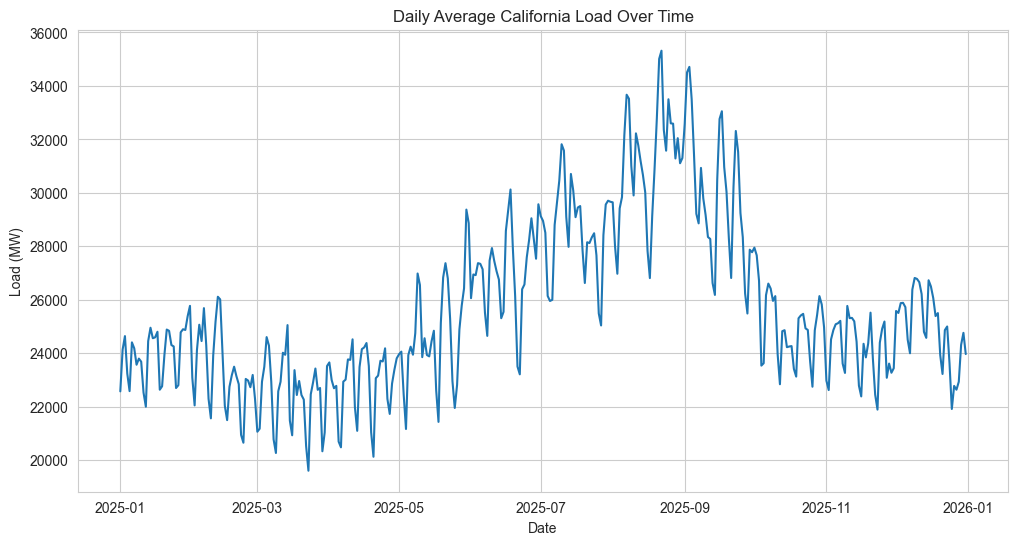

In [4]:
sns.lineplot(data=daily_df, x="datetime", y="load_mw_mean")
plt.title("Daily Average California Load Over Time")
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.show()

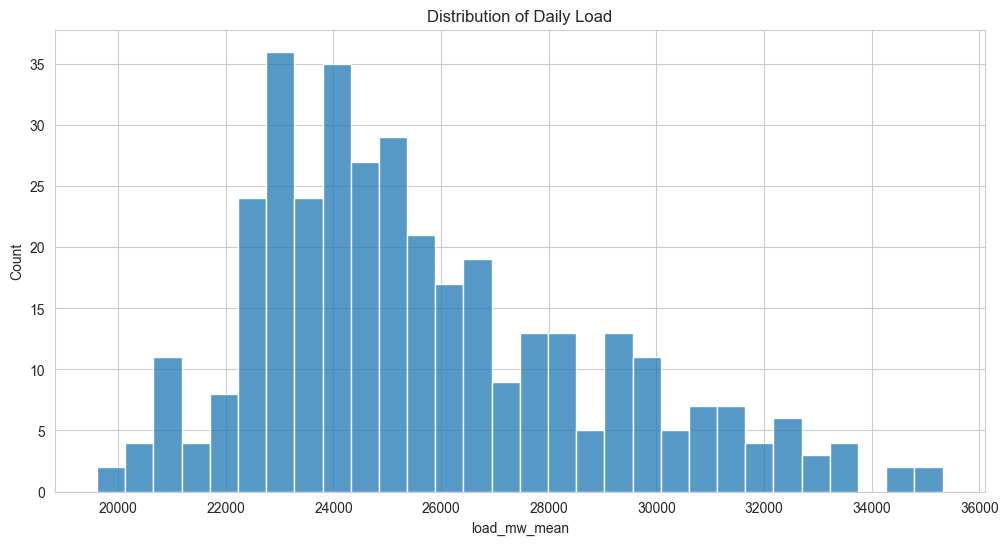

In [5]:
sns.histplot(daily_df["load_mw_mean"], bins=30)
plt.title("Distribution of Daily Load")
plt.show()

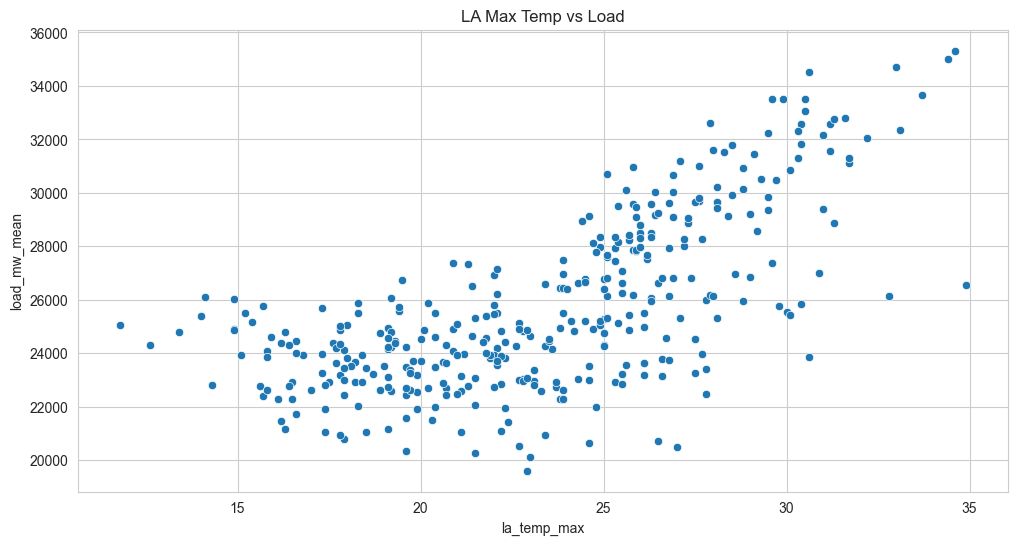

In [6]:
sns.scatterplot(
    data=daily_df,
    x="la_temp_max",
    y="load_mw_mean"
)
plt.title("LA Max Temp vs Load")
plt.show()

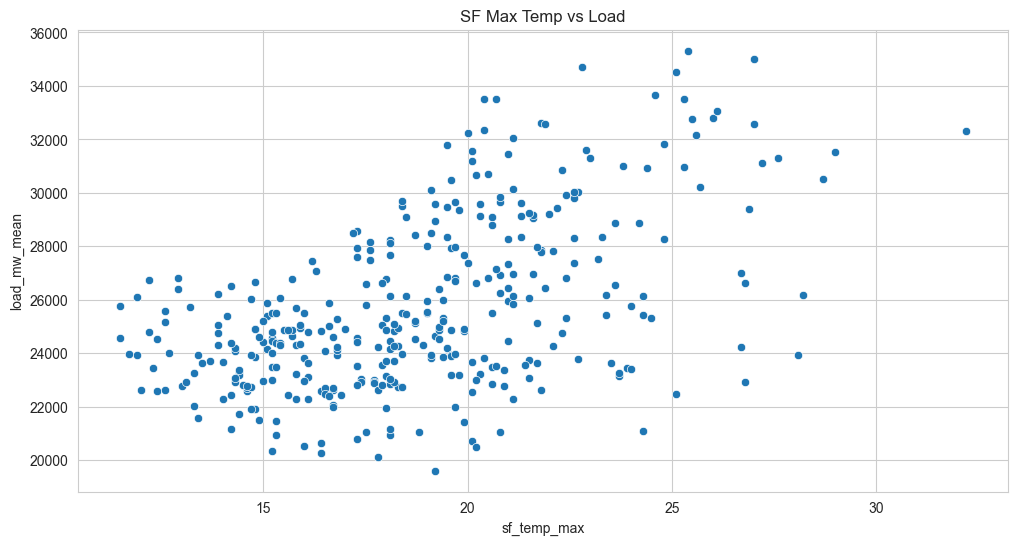

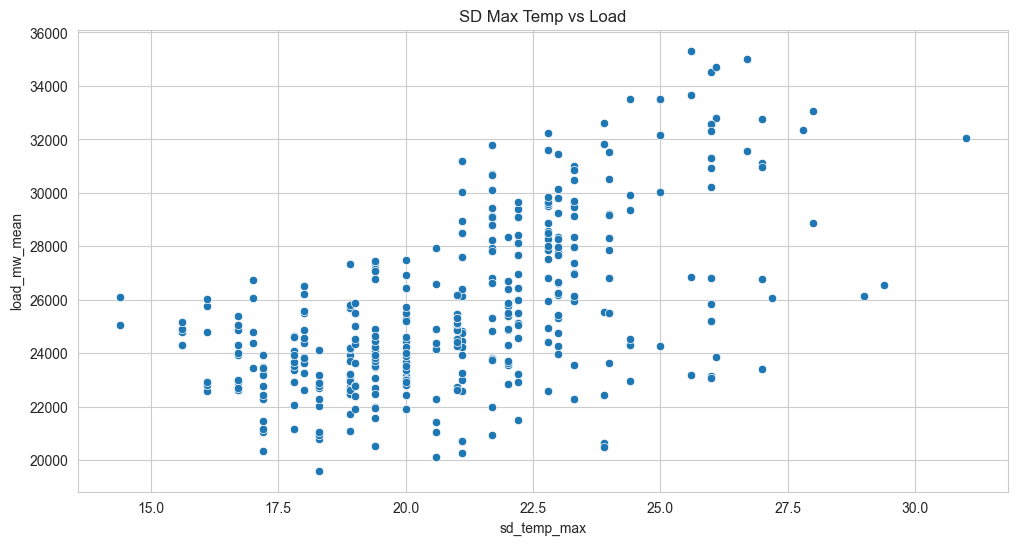

In [7]:
sns.scatterplot(data=daily_df, x="sf_temp_max", y="load_mw_mean")
plt.title("SF Max Temp vs Load")
plt.show()

sns.scatterplot(data=daily_df, x="sd_temp_max", y="load_mw_mean")
plt.title("SD Max Temp vs Load")
plt.show()

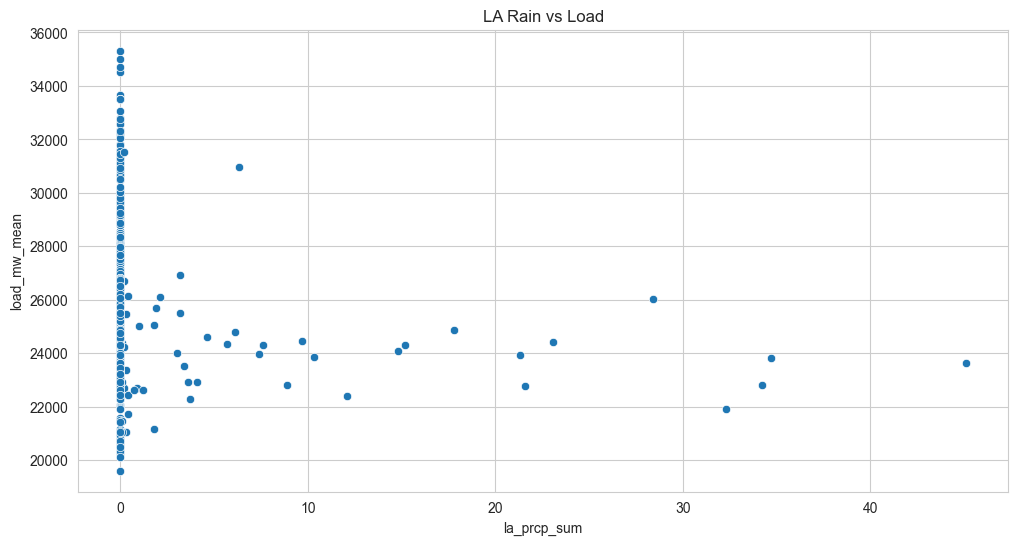

In [8]:
sns.scatterplot(data=daily_df, x="la_prcp_sum", y="load_mw_mean")
plt.title("LA Rain vs Load")
plt.show()

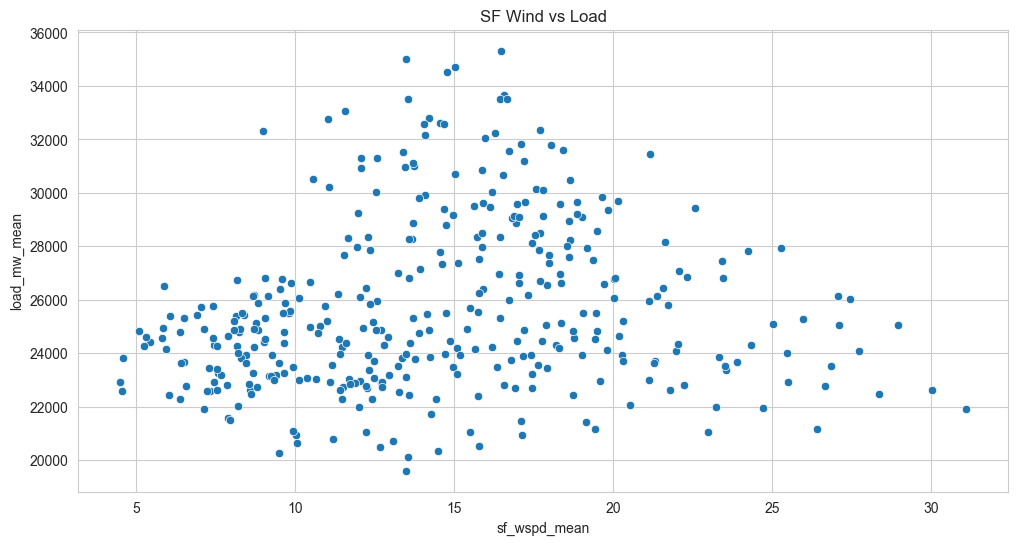

In [9]:
sns.scatterplot(data=daily_df, x="sf_wspd_mean", y="load_mw_mean")
plt.title("SF Wind vs Load")
plt.show()

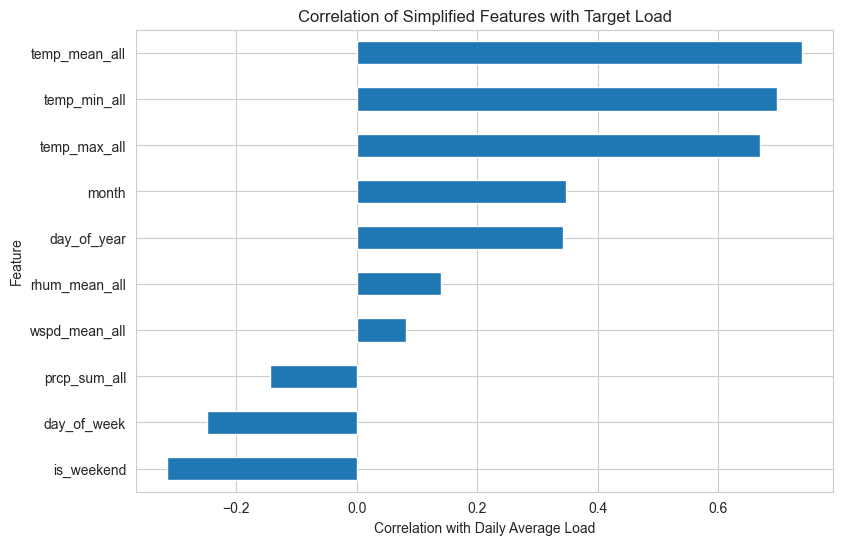

In [10]:
# aggregated weather features across cities
daily_df["temp_mean_all"] = daily_df[["la_temp_mean", "sf_temp_mean", "sd_temp_mean"]].mean(axis=1)
daily_df["temp_max_all"] = daily_df[["la_temp_max", "sf_temp_max", "sd_temp_max"]].mean(axis=1)
daily_df["temp_min_all"] = daily_df[["la_temp_min", "sf_temp_min", "sd_temp_min"]].mean(axis=1)

daily_df["rhum_mean_all"] = daily_df[["la_rhum_mean", "sf_rhum_mean", "sd_rhum_mean"]].mean(axis=1)
daily_df["prcp_sum_all"] = daily_df[["la_prcp_sum", "sf_prcp_sum", "sd_prcp_sum"]].mean(axis=1)
daily_df["wspd_mean_all"] = daily_df[["la_wspd_mean", "sf_wspd_mean", "sd_wspd_mean"]].mean(axis=1)

eda_cols = [
    "temp_mean_all",
    "temp_max_all",
    "temp_min_all",
    "rhum_mean_all",
    "prcp_sum_all",
    "wspd_mean_all",
    "month",
    "day_of_week",
    "day_of_year",
    "is_weekend",
    "target_load_mw_mean"
]

target_corr_simple = (
    daily_df[eda_cols]
    .corr(numeric_only=True)["target_load_mw_mean"]
    .drop("target_load_mw_mean")
    .sort_values()
)

plt.figure(figsize=(9, 6))
target_corr_simple.plot(kind="barh")
plt.title("Correlation of Simplified Features with Target Load")
plt.xlabel("Correlation with Daily Average Load")
plt.ylabel("Feature")
plt.show()

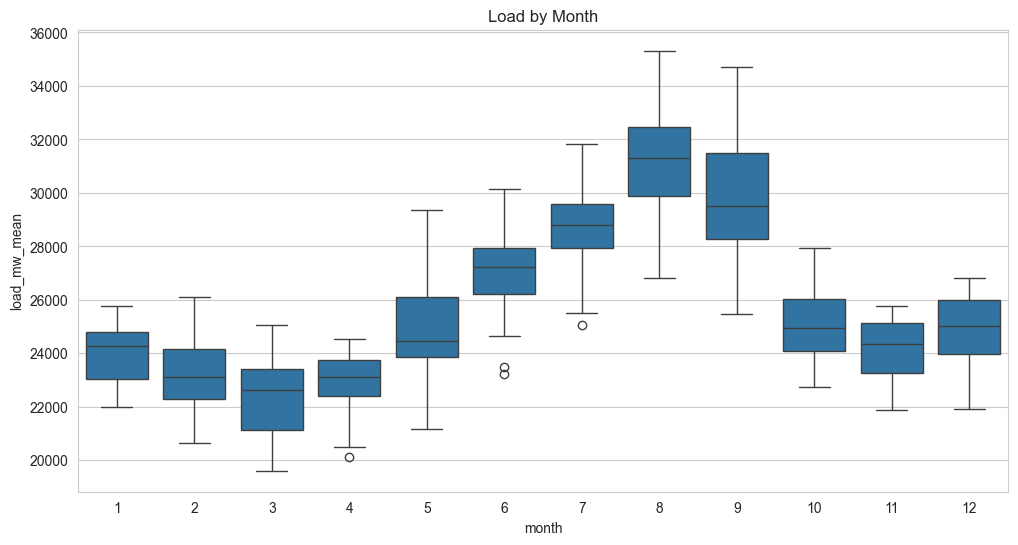

In [11]:
sns.boxplot(x="month", y="load_mw_mean", data=daily_df)
plt.title("Load by Month")
plt.show()

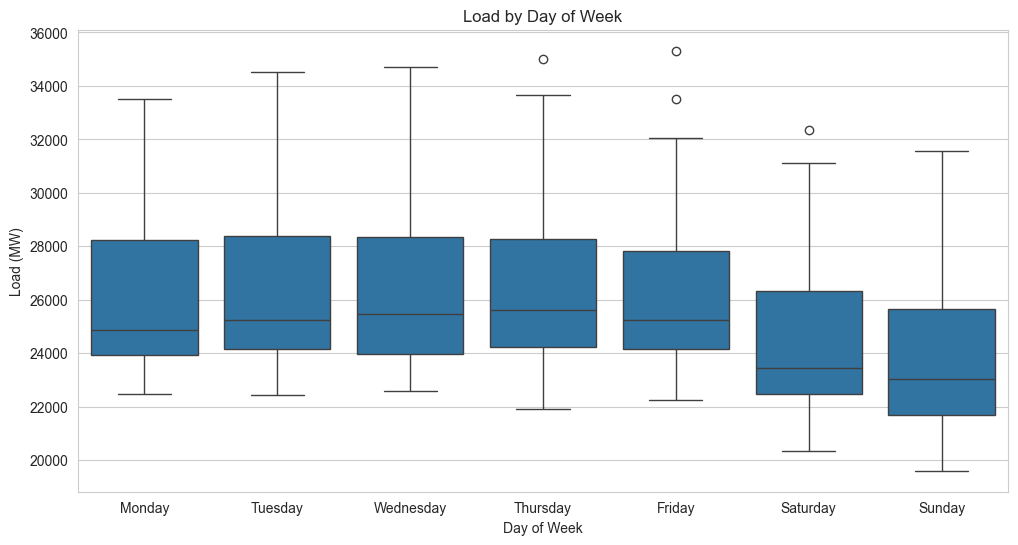

In [12]:
sns.boxplot(
    x="day_name",
    y="load_mw_mean",
    data=daily_df,
    order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
)

plt.title("Load by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Load (MW)")
plt.show()

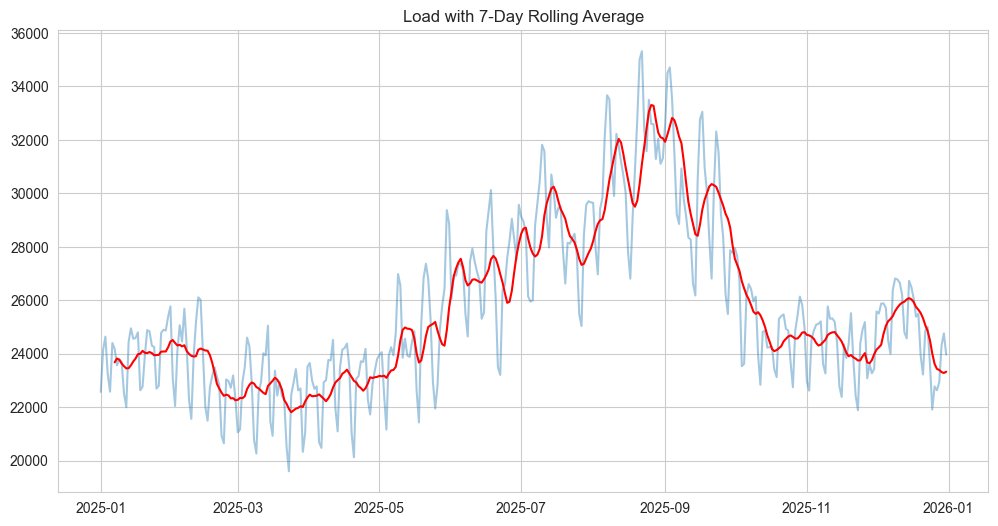

In [13]:
daily_df["rolling_7"] = daily_df["load_mw_mean"].rolling(7).mean()

plt.plot(daily_df["datetime"], daily_df["load_mw_mean"], alpha=0.4)
plt.plot(daily_df["datetime"], daily_df["rolling_7"], color="red")
plt.title("Load with 7-Day Rolling Average")
plt.show()

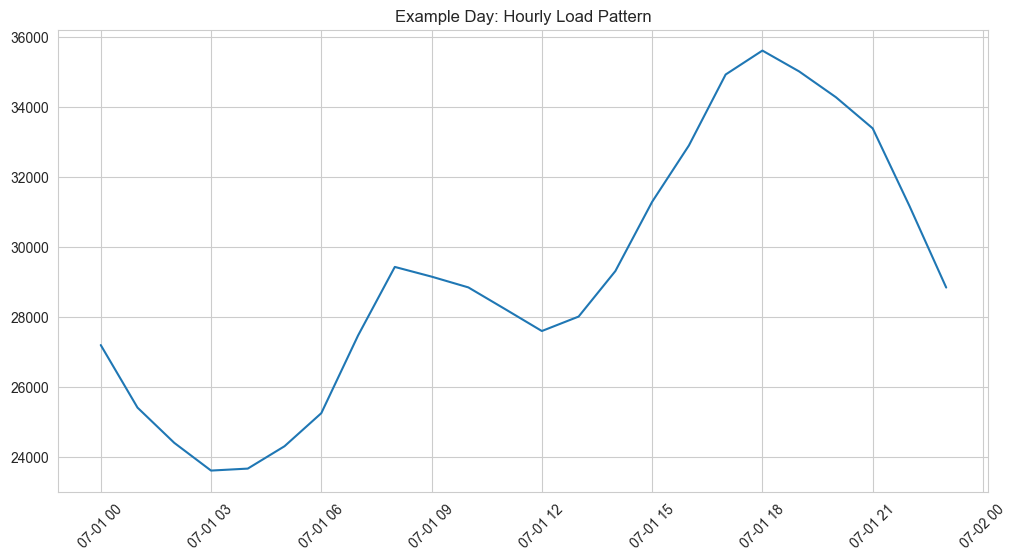

In [14]:
sample_day = hourly_df[
    (hourly_df["datetime"] >= "2025-07-01") &
    (hourly_df["datetime"] < "2025-07-02")
]

plt.plot(sample_day["datetime"], sample_day["load_mw"])
plt.title("Example Day: Hourly Load Pattern")
plt.xticks(rotation=45)
plt.show()

## EDA Summary

- **Clear seasonal pattern in demand**
  - Load rises from spring into late summer, peaking around August–September, then declines into winter.
  - Consistent with increased cooling demand.

- **Temperature is the dominant driver**
  - Higher temperatures strongly correlate with higher load, especially max temperature.
  - Signal is strongest in LA but present across all cities.

- **Weekday vs weekend effect**
  - Demand is higher on weekdays and lowest on Sundays.
  - Likely driven by commercial and industrial activity.

- **Consistent daily load cycle**
  - Hourly data shows predictable patterns: low overnight, ramp in the morning, peak in late afternoon/evening.

- **Other weather features are weaker**
  - Humidity, wind, and precipitation show relatively low correlation with load.
  - Precipitation has a slight negative relationship.

- **Calendar features add important signal**
  - Month and day-of-year capture seasonality.
  - Day-of-week and weekend flags capture behavior patterns.

- **Multi-city weather improves representation**
  - Combining LA, SF, and SD better reflects statewide conditions than a single location.

---

**Takeaway:**  
California electricity demand is driven primarily by temperature, with additional influence from seasonality and human behavior patterns. These insights guide feature selection for modeling.